<div style="border: 5px solid black; padding: 10px;">
    
# **Name:** Tim Hollis  
# **Course:** DSC540 - Data Preparation  
# **Date:**  02/26/2026
# **Assignment:** Week 9 & 10 Exercises 

## Initial Setup:

In [91]:
# Load Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from IPython.display import display
import matplotlib.ticker as mticker


import requests
from bs4 import BeautifulSoup
import re

import urllib.request
import urllib.parse
import urllib.error
import json

import os
from pathlib import Path

# Ignore openxl warning
warnings.simplefilter('ignore', UserWarning)

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)

# Set base directory to the same folder as notebook
BASE_DIR = Path.cwd()
print(f'Working directory set to: {BASE_DIR}')
print()

# Loading Dataset for Activity 4
spotify_df = pd.read_csv('SpotifyDaily.csv')

# Preview Dataset for Activity 4
print('Preview of Dataset for Activity 4:')
print()
display(spotify_df.head())

print('Initial setup complete.')

Working directory set to: C:\Users\slimt\DSC540

Preview of Dataset for Activity 4:



,Position,Track Name,Artist,Streams,URL,Date,Region
0,1,Reggaetón Lento (Bailemos),CNCO,19272,https://open.spotify.com/track/3AEZUABDXNtecAO...,2017-01-01,ec
1,2,Chantaje,Shakira,19270,https://open.spotify.com/track/6mICuAdrwEjh6Y6...,2017-01-01,ec
2,3,Otra Vez (feat. J Balvin),Zion & Lennox,15761,https://open.spotify.com/track/3QwBODjSEzelZyV...,2017-01-01,ec
3,4,Vente Pa' Ca,Ricky Martin,14954,https://open.spotify.com/track/7DM4BPaS7uofFul...,2017-01-01,ec
4,5,Safari,J Balvin,14269,https://open.spotify.com/track/6rQSrBHf7HlZjtc...,2017-01-01,ec


Initial setup complete.


<hr style="height:2px; background-color:#999; border:none; margin:30px 0;">

# **Activity 7.01 – Extracting the Top 100 eBooks from Project Gutenberg**

For this activity, the instructions are to scrape the Project Gutenberg “Top 100 eBooks” page to extract the file numbers and titles of the top 100 eBooks (yesterday’s ranking). This involves using `requests` to retrieve the HTML, `BeautifulSoup` to parse the page, and regular expressions to extract numeric IDs and clean text.

### **Steps to Complete**

1. Read the HTML from the Project Gutenberg Top 100 page.  
2. Write a helper function to check the status of the web request.  
3. Decode the response and pass it to BeautifulSoup for parsing.  
4. Extract all `href` attributes and print the first 30 to inspect the structure.  
5. Use a regular expression to extract numeric file IDs from the links.  
6. Initialize an empty list and collect all file numbers using `re.findall()`.  
7. Inspect the raw text of the soup object (first 2,000 characters only).  
8. Locate the “Top 100 EBooks yesterday” section using `splitlines()`.  
9. Loop through the next 100 lines to collect the raw title strings.  
10. Use a regular expression to extract clean title text from each line.  
11. Print the final list of extracted titles.

<hr style="height:2px; background-color:#999; border:none; margin:30px 0;">

In [92]:
# 1. Read HTML from the Gutenberg Top 100 page
url = 'https://www.gutenberg.org/browse/scores/top'
response = requests.get(url)

# 2. Helper function to check request status


def check_status(resp):
    """Checks status code of a request and prints the result"""

    if resp.status_code == 200:
        print('Request successful.')
    else:
        print(f'Request failed with status code: {resp.status_code}')


check_status(response)

# 3. Decode and parse with BeautifulSoup
html = response.text
soup = BeautifulSoup(html, 'html.parser')

# 4. Extract all href links
links = [a.get('href') for a in soup.find_all('a', href=True)]
print('\nFirst 30 extracted links:')
print(links[:30])

# 5–6. Extract numeric file IDs using regex
file_numbers = []
for link in links:
    nums = re.findall(r'\d+', link)
    if nums:
        file_numbers.extend(nums)

print(f'\nTotal numeric file references found: {len(file_numbers)}')
print('First 30 file numbers:', file_numbers[:30])

# 7. Inspect first 2,000 characters of text (removing blank lines)
clean_text = '\n'.join(line for line in soup.text.splitlines() if line.strip())
print('\nFirst 2,000 characters of text:')
print(clean_text[:2000])

# 8. Locate the prior days' Top 100 Ebooks
lines = clean_text.splitlines()
start_index = None

for i, line in enumerate(lines):
    if 'Top 100 EBooks yesterday' in line:
        start_index = i
        break

print(f'\nStart index for Top 100 section: {start_index}')

# 9. Collect the next 100 lines (raw titles)
raw_titles = []
for i in range(start_index + 1, start_index + 101):
    raw_titles.append(lines[i])

# 10. Extract clean titles using regex
clean_titles = []
for entry in raw_titles:
    entry = entry.strip()
    match = re.match(r'^(.*)\s\(\d+\)\s*$', entry)
    if match:
        clean_titles.append(match.group(1))
    else:
        clean_titles.append(entry)

# 11. Print final list of titles
print('\nExtracted Top 100 eBook Titles:')
for t in clean_titles:
    print(t)

Request successful.

First 30 extracted links:
['/', '/donate/', '/about/', '/help/reading_options.html', '/about/contact_information.html', '/about/background/', '/help/', '/ebooks/offline_catalogs.html', '/donate/', '/browse/scores/top', '/ebooks/categories', '/ebooks/bookshelf/', '/ebooks/', '/browse/scores/top', '/ebooks/categories', '/about/pretty-pictures.html', '#books-last1', '#books-last7', '#books-last30', '#authors-last1', '#authors-last7', '#authors-last30', '/ebooks/84', '/ebooks/768', '/ebooks/2701', '/ebooks/45304', '/ebooks/1342', '/ebooks/27166', '/ebooks/1513', '/ebooks/27060']

Total numeric file references found: 642
First 30 file numbers: ['1', '7', '30', '1', '7', '30', '84', '768', '2701', '45304', '1342', '27166', '1513', '27060', '25229', '64317', '27332', '11', '43', '2641', '100', '145', '2542', '27459', '844', '165', '1260', '6271', '67979', '37106']

First 2,000 characters of text:
Top 100 | Project Gutenberg
X
Go!
 Donate 
About▼
About Project Gutenberg 
R

<div style="border: 2px solid black; padding: 10px;">

## **Summary**

In this activity, I scraped the Project Gutenberg “Top 100 eBooks” page to extract both the numeric file identifiers and the titles of the top 100 most‑downloaded eBooks (yesterday’s ranking). I used `requests` to retrieve the HTML, `BeautifulSoup` to parse the page, and regular expressions to isolate numeric IDs and clean title text.

After confirming a successful web request, I parsed the HTML and collected all `href` attributes to inspect the structure of the links. Using `re.findall()`, I extracted all numeric sequences appearing in those links, which included the file numbers associated with the eBooks.

To work with the page text, I removed blank lines from `soup.text` to avoid large whitespace gaps and printed the first 2,000 characters for inspection. I then located the “Top 100 EBooks yesterday” section by searching through the cleaned text with `splitlines()`. Starting from that index, I collected the next 100 lines, each representing a title entry.

Finally, I used a regular expression to extract the title text from each line by removing the trailing download count in parentheses. The result was a clean list of the Top 100 eBook titles, printed one per line.

# **Activity 7.02 – Building a Movie Database Using the OMDb API**

In this activity, I connect to the OMDb API to retrieve movie information based on a user‑entered title. The goal is to read JSON data returned from the API, print key movie attributes, and download the movie poster when available. This activity uses `urllib` for making API requests, `json` for decoding the response, and `os` for saving poster files locally.

### **Steps to Complete**

1. Load API key
2. Assign the OMDb service URL (`http://www.omdbapi.com/?`) to a variable.
3. Create an `apikey` variable containing the URL parameter `&apikey=secretapikey`.
4. Write a utility function `print_json` to neatly print the JSON movie data returned by the API.
5. Write a utility function to download and save the movie poster using the `Poster` field from the JSON response.
6. Write a `search_movie` function that:
   - Accepts a movie title as input  
   - Builds the full API request URL using `urllib.parse.urlencode()`  
   - Retrieves the JSON data  
   - Checks the `Response` field to determine success  
   - Prints the movie information  
   - Downloads the poster if available  
   - Handles errors using a `try–except` block  
7. Test the `search_movie` function using the movie title **Girls Trip**.
8. Test the function again using **Random_error** to confirm that error handling works correctly.

<hr style="height:2px; background-color:#999; border:none; margin:30px 0;">

In [93]:
# 1. Load API key
try:
    with open('APIkeys.json', 'r') as f:
        keys = json.load(f)
        # Assumes your JSON has: {"omdb": "your_key_here"}
        api_key = keys['omdb']
    print("Successfully loaded OMDb API key from APIkeys.json")
except FileNotFoundError:
    print("ERROR: 'APIkeys.json' not found in the current notebook folder!")
    raise  # Stop execution so you know to fix it
except KeyError:
    print("ERROR: 'omdb' key not found in APIkeys.json – check the file contents")
    raise
except json.JSONDecodeError:
    print("ERROR: Invalid JSON format in APIkeys.json – make sure to use double quotes!")
    raise
except Exception as e:
    print(f"ERROR loading API key: {e}")
    raise

# 2. Base OMDb service URL
serviceurl = 'http://www.omdbapi.com/?'

# 3. Build the API key parameter
apikey = '&apikey=' + api_key

# 4. Helper function to print movie details nicely


def print_json(data):
    """Prints selected movie attributes from an OMDb API JSON response."""
    print('Title:', data.get('Title', 'N/A'))
    print('Year:', data.get('Year', 'N/A'))
    print('Rated:', data.get('Rated', 'N/A'))
    print('Released:', data.get('Released', 'N/A'))
    print('Runtime:', data.get('Runtime', 'N/A'))
    print('Genre:', data.get('Genre', 'N/A'))
    print('Director:', data.get('Director', 'N/A'))
    print('Actors:', data.get('Actors', 'N/A'))
    print('Plot:', data.get('Plot', 'N/A'))
    print('Poster:', data.get('Poster', 'N/A'))
    print()

# 5. Download and save movie poster


def download_poster(poster_url, title):
    """Downloads and saves a movie poster image from the OMDb API response."""
    if poster_url == 'N/A':
        print('No poster available for this movie.\n')
        return
    try:
        filename = title.replace(' ', '_') + '_poster.jpg'
        urllib.request.urlretrieve(poster_url, filename)
        print('Poster downloaded as:', filename, '\n')
    except Exception as e:
        print('Error downloading poster:', e, '\n')

# 6. Main search function


def search_movie(title):
    """Searches the OMDb API for a movie by title"""
    try:
        # Build query parameters
        params = urllib.parse.urlencode({'t': title})
        url = serviceurl + params + apikey
        print(f"Request URL: {url}\n")

        # Request data
        uh = urllib.request.urlopen(url)
        data = uh.read().decode()

        # Convert JSON string to dictionary
        js = json.loads(data)

        # Check for valid response
        if js.get('Response') == 'False':
            print('Movie not found:', title)
            print('Error message:', js.get('Error', 'Unknown error'), '\n')
            return

        # Print movie info
        print_json(js)

        # Download poster
        download_poster(js.get('Poster', 'N/A'), js.get('Title', 'movie'))

    except urllib.error.URLError as e:
        print('URL Error:', e.reason, '\n')
    except Exception as e:
        print('General Error:', e, '\n')


# 7-8 Test by searching valid/invalid titles
print('Valid Movie Search:')
print('───────────────────')
search_movie('Girls Trip')

print('\nInvalid Movie Search:')
print('─────────────────────')
search_movie('Random_error')

Successfully loaded OMDb API key from APIkeys.json
Valid Movie Search:
───────────────────
Request URL: http://www.omdbapi.com/?t=Girls+Trip&apikey=54ff0e59

Title: Girls Trip
Year: 2017
Rated: R
Released: 21 Jul 2017
Runtime: 122 min
Genre: Adventure, Comedy, Drama
Director: Malcolm D. Lee
Actors: Regina Hall, Queen Latifah, Jada Pinkett Smith
Plot: When four lifelong friends travel to New Orleans for the annual Essence Festival, sisterhoods are rekindled, wild sides are rediscovered, and there's enough dancing, drinking, brawling and romancing to make the Big Easy blush.
Poster: https://m.media-amazon.com/images/M/MV5BMjMwNTEzODUwMV5BMl5BanBnXkFtZTgwNjE5NjA5MjI@._V1_SX300.jpg

Poster downloaded as: Girls_Trip_poster.jpg 


Invalid Movie Search:
─────────────────────
Request URL: http://www.omdbapi.com/?t=Random_error&apikey=54ff0e59

Movie not found: Random_error
Error message: Movie not found! 



<div style="border: 2px solid black; padding: 10px;">

## **Summary**

In this activity, I built a movie-lookup tool that interacts with the **OMDb API** to retrieve information about any movie title entered by the user. The tool sends an HTTP request to the OMDb service, processes the returned JSON data, displays selected key attributes (such as Title, Year, Director, Plot, etc.), and downloads the movie poster image when available.

To follow best practices and meet the assignment requirements, I obtained a personal API key from the OMDb website and stored it securely in a separate JSON file (`APIkeys.json`) in the same folder as the notebook. The code loads this key at runtime, constructs the full API request URL, and handles both successful and failed lookups.

I created three main components:
- A helper function (`print_json`) to neatly display important movie details from the JSON response.
- A function (`download_poster`) to download and save the poster image locally (with proper error checking).
- The core `search_movie` function, which builds the query, sends the request, checks the `"Response"` field for success, prints the movie information if valid, downloads the poster, or displays the appropriate error message if the movie is not found.

For testing:
- I searched for the valid movie **Girls Trip** — the function returned complete movie details (including metadata like Year, Rated, Genre, Plot, etc.) and successfully downloaded the poster as `Girls_Trip_poster.jpg`.
- I then tested an invalid title (**Random_error**) — the code correctly detected the failure, printed the OMDb error message ("Movie not found!"), and did not attempt to download a poster.

<hr style="height:2px; background-color:#999; border:none; margin:30px 0;">

# **Activity 3 – Connecting to an API and Performing a Simple GET Request**

### **API Selected**
**Random Programming Joke Endpoint:**  
https://official-joke-api.appspot.com/jokes/programming/random

This endpoint returns a list containing one programming‑related joke, including fields such as `id`, `type`, `setup`, and `punchline`.

### **Steps to Complete**

1. Assign the API endpoint URL to a variable.
2. Use `urllib.request.urlopen()` to send a GET request to the API.
3. Read and decode the response returned by the server.
4. Convert the JSON string into a Python dictionary using `json.loads()`.
5. Print a subset of the returned data (for example, the joke setup and punchline).
6. Add a `try–except` block to handle potential connection errors or invalid responses.

<hr style="height:2px; background-color:#999; border:none; margin:30px 0;">

In [94]:
# 1. Base URL for the API (no key required)
joke_url = 'https://official-joke-api.appspot.com/jokes/programming/random'


def get_programming_joke():
    """
    Fetches a random programming joke from the Official Joke API.
    Sends a GET request to the API, decodes the JSON response,
    and prints the joke.
    """
    try:
        # 2-3. Send GET request and read/decode response
        response = urllib.request.urlopen(joke_url)
        data = response.read().decode()

        # 4. Convert JSON string to Python object
        js = json.loads(data)

        # 5. Print subset of data
        if isinstance(js, list) and len(js) > 0:
            joke = js[0]
            print('Setup:', joke.get('setup', 'N/A'))
            print('Punchline:', joke.get('punchline', 'N/A'))
            print()
        else:
            print('Unexpected response format.\n')
    # 6. Error handling
    except urllib.error.URLError as e:
        print('URL Error:', e.reason)
    except Exception as e:
        print('General Error:', e)


get_programming_joke()

Setup: Why did the developer go broke?
Punchline: They kept spending all their cache.



<div style="border: 2px solid black; padding: 10px;">

## **Summary**

In this activity, I connected to the **Official Joke API** using a simple GET request to retrieve a random programming joke. This API was selected because it requires no authentication, no API key, and no signup, making it ideal for demonstrating the fundamentals of API interaction. The goal of the activity was to construct a request URL, send the request, decode the JSON response, and display a subset of the returned data.

To complete the task, I assigned the API endpoint URL to a variable and used `urllib.request.urlopen()` to send the GET request. After reading and decoding the response, I converted the JSON string into a Python dictionary using `json.loads()`. Since the API returns a list containing a single joke object, I extracted the `setup` and `punchline` fields and printed them in a readable format. I also included basic error handling to manage potential connection issues or unexpected response formats.

# Activity 4: Data Visualization with Spotify Daily Streaming Data

## Data Attribution

The dataset used in this activity is **Spotify Worldwide Daily Song Ranking**, originally published on Kaggle by Eduardo. The dataset contains daily chart positions, stream counts, artists, tracks, and regional information collected from Spotify’s public charts.

**Source:**  
Eduardo. (2018). *Spotify Worldwide Daily Song Ranking* [Dataset]. Kaggle. https://www.kaggle.com/datasets/edumucelli/spotify-daily-chart

This dataset was downloaded directly from Kaggle and saved locally as **SpotifyDaily.csv** for use in this notebook.

---

## Dataset Overview
- **Position**: Chart ranking for the track on a given day  
- **Track Name**: Title of the song  
- **Artist**: Performing artist  
- **Streams**: Number of daily streams  
- **Date**: Chart date  
- **Region**: Country/region code  

**Note: This dataset covers daily Spotify chart data from January 1, 2017 through January 9, 2018.**
---

## Tasks for This Activity

Though only three visualizations are required, I will complete all six, each with a setup section, a visualization, and a summary.

<div style="border: 2px solid black; padding: 10px;">

| Visualization Type | Use Case | Spotify Columns Used |
|--------------------|----------|-----------------------|
| **Line Plot** | Analyzing how streams change over time for a song in the US compared to Czechia for 1-800-273-8255 | `Date`, `Streams`, `Track Name` |
| **Scatter Plot** | Examining the relationship between Streams and Position | `Streams`, `Position` |
| **Bar Chart** | Comparing Top 10 Artists by total streams | `Artist`, aggregated `Streams` |
| **Pie Chart** | Showing Top 5 Artists | `Artist`, aggregated `Streams` |
| **Histogram** | Understanding the distribution of daily stream counts | `Streams` |
| **Density Plot** | Viewing a smoothed distribution of streams to identify patterns or skew | `Streams` |
 

</div>

## 4.1 Line Plot — Daily Streams per Million People (US vs. Czechia)

**Steps to Complete**

1. Filter the dataset to include only the selected track and the two regions (`us`, `cz`).
2. Convert the `Date` column to datetime format and sort by region and date.
3. Normalize daily streams to streams per million inhabitants using 2017 population values.
4. Reindex the data to fill missing dates and ensure a continuous time series.
5. Create a line plot comparing normalized daily streams for the US and Czechia.
6. Calculate and print peak normalized stream values for each country.

---

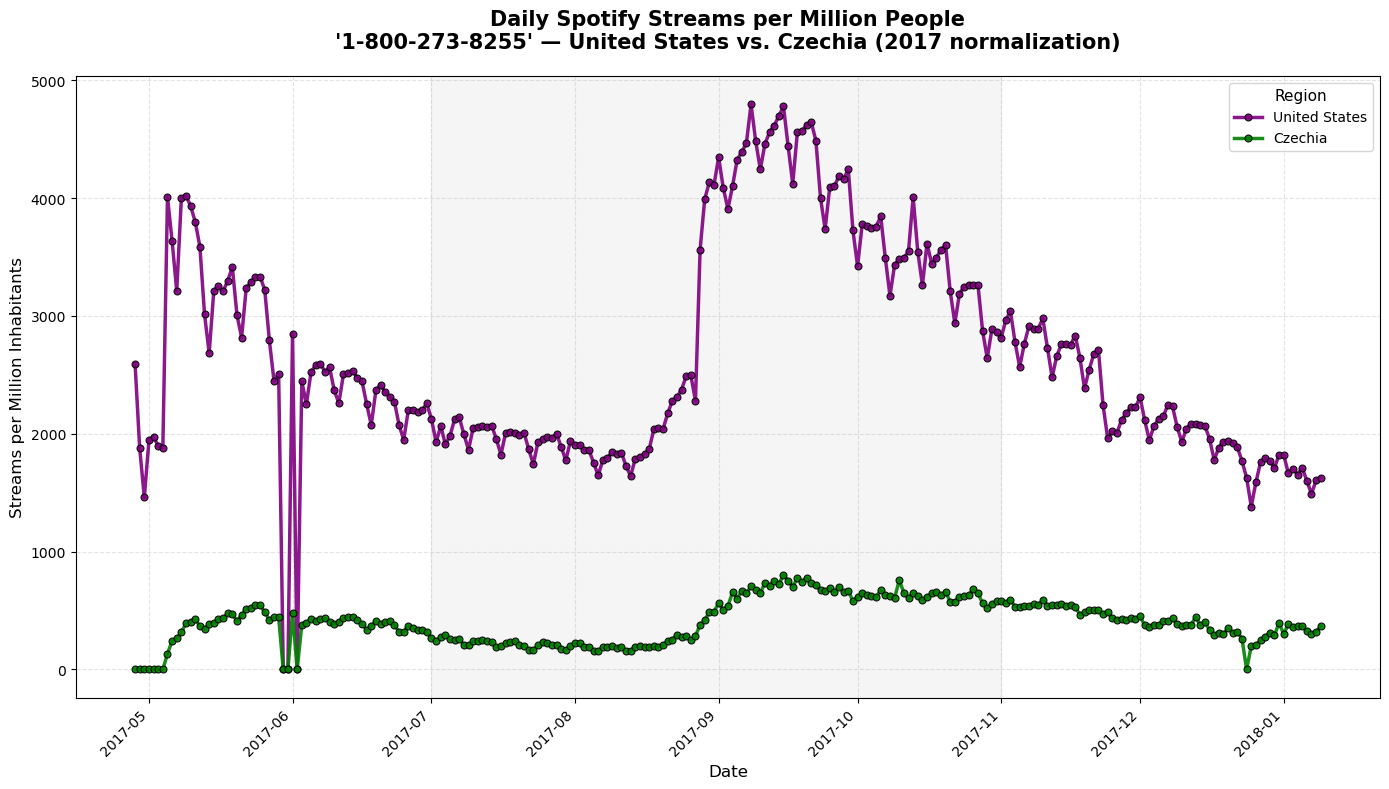

Peak US: 4796.101 streams per million people
Peak Czechia: 801.491 streams per million people
→ Czechia's peak is ~0.2x the US level (lower relative to population).


In [95]:
# 1. Filter the dataset to include only the selected track and the two regions
POP_US_2017 = 325_122_000
POP_CZ_2017 = 10_594_000

track_name = '1-800-273-8255'
regions = ['us', 'cz']

compare_df = spotify_df[
    (spotify_df['Track Name'] == track_name) &
    (spotify_df['Region'].isin(regions))
].copy()

# 2. Convert the Date column to datetime and sort
compare_df['Date'] = pd.to_datetime(compare_df['Date'])
compare_df = compare_df.sort_values(['Region', 'Date'])

# 3. Normalize daily streams to streams per million inhabitants
pop_map = {'us': POP_US_2017, 'cz': POP_CZ_2017}
compare_df['Streams_per_Million'] = (
    compare_df['Streams'] / compare_df['Region'].map(pop_map) * 1_000_000
)

# 4. Reindex to fill missing dates for a continuous time series
all_dates = pd.date_range(
    compare_df['Date'].min(),
    compare_df['Date'].max(),
    freq='D')

filled_df = (compare_df .set_index(['Region',
                                    'Date']) .reindex(pd.MultiIndex.from_product([regions,
                                                                                  all_dates],
                                                                                 names=['Region',
                                                                                        'Date'])) .fillna({'Streams': 0,
                                                                                                           'Streams_per_Million': 0,
                                                                                                           'Track Name': track_name}) .reset_index())

# 5. Create the line plot comparing normalized daily streams
plt.figure(figsize=(14, 8))

sns.lineplot(
    data=filled_df,
    x='Date',
    y='Streams_per_Million',
    hue='Region',
    hue_order=['us', 'cz'],
    palette={'us': 'purple', 'cz': 'green'},
    linewidth=2.5,
    marker='o',
    markersize=5,
    markeredgecolor='black',
    markeredgewidth=0.8,
    alpha=0.9
)

plt.title(
    f"Daily Spotify Streams per Million People\n"
    f"'{track_name}' — United States vs. Czechia (2017 normalization)",
    fontsize=15, fontweight='bold', pad=20
)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Streams per Million Inhabitants', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(True, ls='--', alpha=0.35)

# Correct legend: pull actual handles/labels, then rename (this took a few
# attempts for me for some reason)
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(
    handles=handles,
    labels=['United States', 'Czechia'],
    title='Region',
    fontsize=10,
    title_fontsize=11
)

plt.axvspan(
    pd.to_datetime('2017-07-01'),
    pd.to_datetime('2017-11-01'),
    color='gray',
    alpha=0.08
)

plt.tight_layout()
plt.show()

# 6. Calculate and print peak normalized stream values
peak_us = filled_df[filled_df['Region'] == 'us']['Streams_per_Million'].max()
peak_cz = filled_df[filled_df['Region'] == 'cz']['Streams_per_Million'].max()
ratio = peak_cz / peak_us if peak_us != 0 else float('nan')

print(f"Peak US: {peak_us:.3f} streams per million people")
print(f"Peak Czechia: {peak_cz:.3f} streams per million people")

if ratio >= 1:
    print(
        f"→ Czechia's peak is ~{ratio:.1f}x higher relative to population than the US.")
else:
    # (This logic also took me a couple tries)
    print(
        f"→ Czechia's peak is ~{ratio:.1f}x the US level (lower relative to population).")

<div style="border: 2px solid black; padding: 10px;">

### Summary

Normalizing daily Spotify streams by population reveals that the United States consistently shows **higher** per‑capita streaming levels for *“1‑800‑273‑8255”* compared to Czechia throughout the observed period. While Czechia demonstrates clear engagement with the track, its peak normalized streaming value remains well below the U.S. peak. The U.S. curve also shows a more pronounced rise during the mid‑2017 surge, aligning with the song’s broader international popularity. Overall, the visualization highlights both countries’ interest in the track, but the U.S. exhibits substantially stronger per‑capita streaming intensity.



## 4.2 Scatter Plot — Relationship Between Streams and Chart Position

**Steps to Complete**

1. Select the two required numeric variables (`Streams` and `Position`) from the dataset.
2. Filter the dataset to include only rows where both `Streams` and `Position` contain valid numeric values.
3. Remove any remaining missing or invalid entries to ensure a clean scatter plot.
4. Create a scatter plot with `Streams` on the x-axis and `Position` on the y-axis.
5. Format the axes, invert the y-axis so Rank 1 appears at the top, and apply visual styling for clarity.
6. Add a title, axis labels, and gridlines to complete the visualization.

---

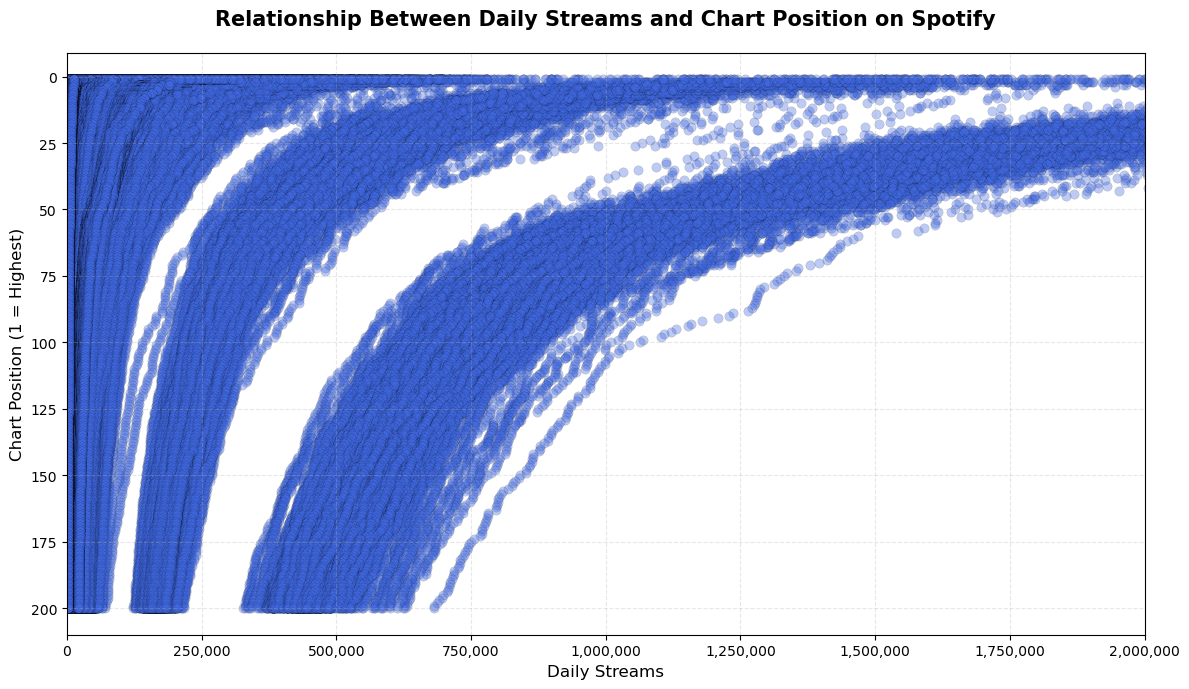

In [96]:
# 1. Select the two required numeric variables (Streams and Position)
scatter_df = spotify_df[['Streams', 'Position']].copy()

# 2. Filter the dataset to include only rows with valid numeric values
scatter_df = scatter_df[
    scatter_df['Streams'].notna() &
    scatter_df['Position'].notna()
]

# 3. Remove any remaining missing or invalid entries
scatter_df = scatter_df.dropna()

# 4. Create a scatter plot with Streams on the x-axis and Position on the
# y-axis
plt.figure(figsize=(12, 7))

sns.scatterplot(
    data=scatter_df,
    x='Streams',
    y='Position',
    alpha=0.35,
    s=45,
    edgecolor='black',
    linewidth=0.2,
    color='#4169E1'
)

# 5. Format axes, invert y-axis, and apply styling
plt.gca().invert_yaxis()

# Disable scientific notation and format with commas
plt.ticklabel_format(style='plain', axis='x')
plt.gca().xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{int(x):,}')
)

plt.xlabel('Daily Streams', fontsize=12)
plt.ylabel('Chart Position (1 = Highest)', fontsize=12)
plt.grid(True, ls='--', alpha=0.3)

# Limit x-axis to improve readability (Spotify streams are heavily skewed)
plt.xlim(0, 2_000_000)

# 6. Add title, labels, and finalize the visualization
plt.title('Relationship Between Daily Streams and Chart Position on Spotify',
          fontsize=15,
          fontweight='bold',
          pad=20
          )

plt.tight_layout()
plt.show()

<div style="border: 2px solid black; padding: 10px;">
    
### Summary 
The scatter plot illustrates how daily Spotify stream counts relate to chart position across the **2017–2018** dataset. After formatting the axes and limiting the x‑range for clarity, a clear pattern emerges: songs with higher daily streams consistently occupy better chart positions, clustering toward the top of the rankings. Most observations fall within lower stream ranges, reflecting the long‑tail distribution of Spotify popularity, while only a small number of tracks achieve the high‑stream, top‑chart positions. Overall, the visualization confirms a strong inverse relationship between streams and chart rank, with higher streaming activity corresponding to better chart performance during the 2017–2018 period.


## 4.3 Bar Chart — Total Streams by Artist (2017–2018)

**Steps to Complete**

1. Select the required columns (`Artist` and `Streams`) from the dataset.
2. Group the data by `Artist` and calculate total streams for each artist across 2017–2018.
3. Sort the aggregated results in descending order to identify the highest‑streaming artists.
4. Select the top artists to include in the bar chart for clear visual comparison.
5. Create a bar chart showing total streams for the selected artists.
6. Format the axes, apply comma formatting to stream values, and add labels and a title.

---

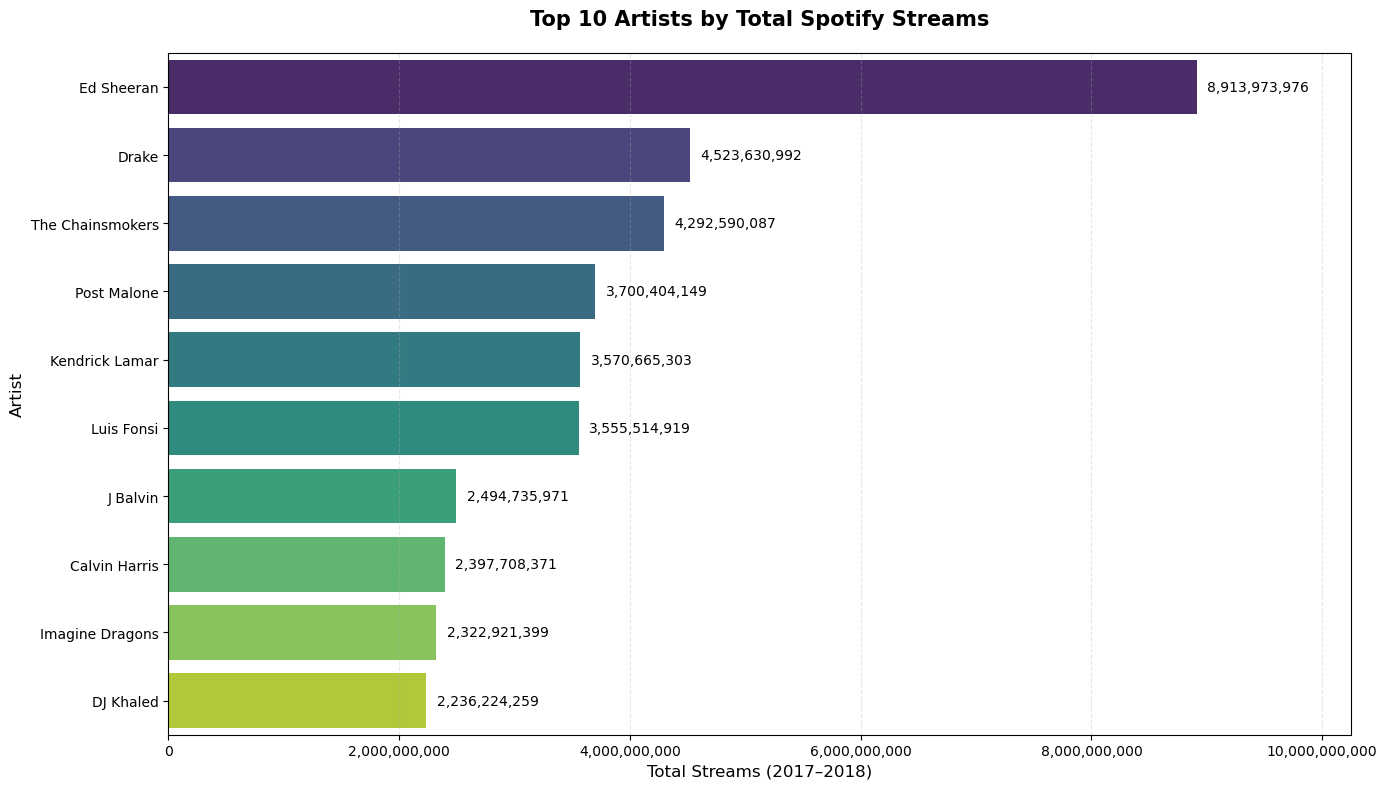

In [97]:
# 1. Select the required columns (Artist and Streams)
bar_df = spotify_df[['Artist', 'Streams']].copy()

# 2. Group the data by Artist and calculate total streams
artist_totals = (
    bar_df
    .groupby('Artist', as_index=False)['Streams']
    .sum()
)

# 3. Sort the aggregated results in descending order
artist_totals = artist_totals.sort_values('Streams', ascending=False)

# 4. Select the top artists for the bar chart
top_artists = artist_totals.head(10)

# 5. Create a bar chart showing total streams for the selected artists
plt.figure(figsize=(14, 8))

ax = sns.barplot(
    data=top_artists,
    x='Streams',
    y='Artist',
    hue='Artist',
    palette='viridis',
    legend=False
)

# Format x-axis with commas
plt.gca().xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{int(x):,}')
)

plt.xlabel('Total Streams (2017–2018)', fontsize=12)
plt.ylabel('Artist', fontsize=12)
plt.grid(True, axis='x', ls='--', alpha=0.3)

max_val = top_artists['Streams'].max()
plt.xlim(0, max_val * 1.15)   # Extended x axis to allow the value to fit

# Add actual values
for bar in ax.patches:
    width = bar.get_width()
    y = bar.get_y() + bar.get_height() / 2
    label = f'{int(width):,}'
    ax.text(
        width + (max_val * 0.01),
        y,
        label,
        va='center',
        ha='left',
        fontsize=10
    )

# 6. Add title and finalize the visualization
plt.title(
    'Top 10 Artists by Total Spotify Streams',
    fontsize=15,
    fontweight='bold',
    pad=20)

plt.tight_layout()
plt.show()

<div style="border: 2px solid black; padding: 10px;">

### Summary

The bar chart highlights the **top 10 artists by total Spotify streams across 2017–2018**, revealing a clear hierarchy in overall listening volume during this period. After aggregating and sorting total streams, one artist stands out with a substantially higher cumulative count, while the remaining artists form a more gradual decline. Adding the numeric labels to the right of each bar makes these differences immediately visible, and extending the x‑axis ensures that even the highest total fits cleanly within the visual frame. Overall, the chart provides a straightforward comparison of artist‑level popularity, showing which performers dominated global streaming activity during the 2017–2018 timeframe.


## 4.4 Pie Chart — Proportional Share of Total Streams by Top Artists (2017–2018)

**Steps to Complete**

1. Select the `Artist` and `Streams` columns from the dataset.
2. Aggregate total streams for each artist to compute overall contributions.
3. Sort artists by total streams and select the top group (e.g., Top 5) for a clear, readable pie chart.
4. Calculate each artist’s percentage share of total streams within the selected group.
5. Create a pie chart showing proportional contributions using distinct, readable colors.
6. Add labels, percentages, a legend if needed, and a title indicating the 2017–2018 timeframe.

---

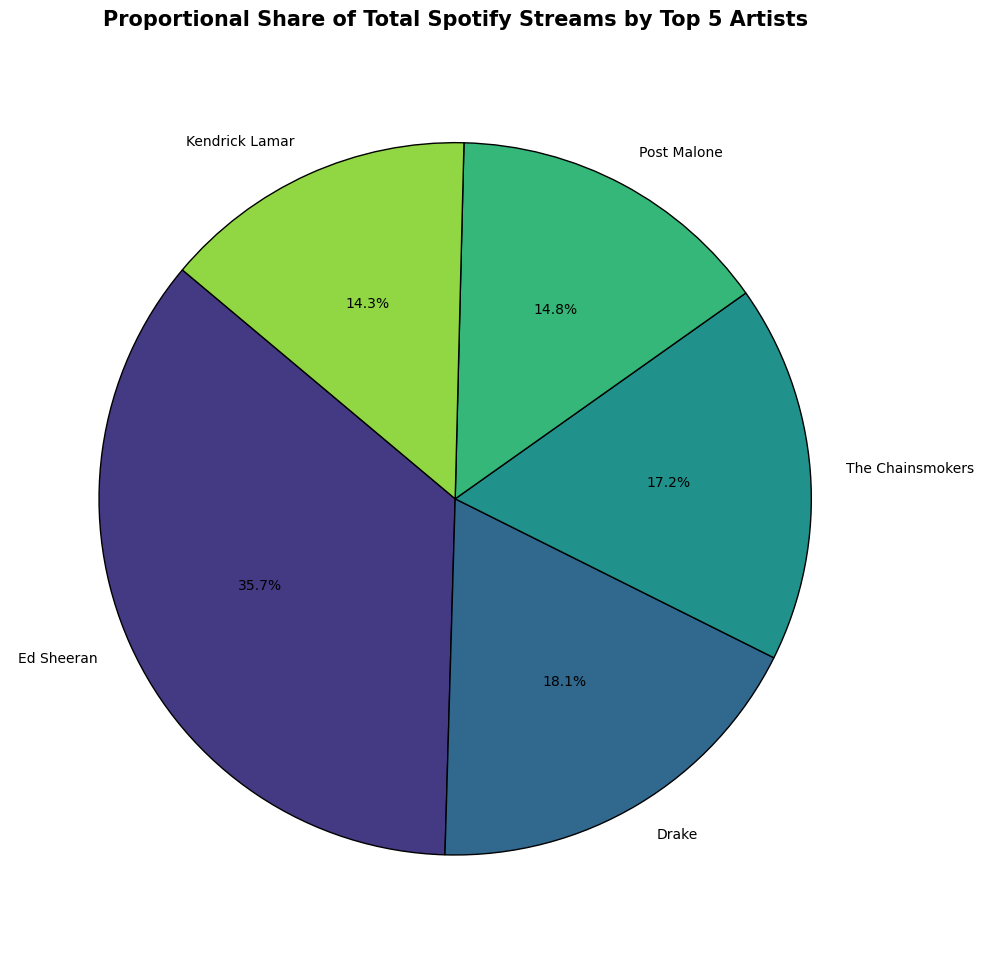

In [98]:
# 1. Select Artist and Streams columns
pie_df = spotify_df[['Artist', 'Streams']].copy()

# 2. Aggregate total streams per artist
artist_totals = (
    pie_df
    .groupby('Artist', as_index=False)['Streams']
    .sum()
)

# 3. Sort and select the top 5 artists for readability
top5 = artist_totals.sort_values('Streams', ascending=False).head(5)

# 4. Calculate percentage share (matplotlib does this automatically, but
# we keep totals clean)
stream_values = top5['Streams']
artist_labels = top5['Artist']

# 5. Create the pie chart
plt.figure(figsize=(10, 10))

plt.pie(
    stream_values,
    labels=artist_labels,
    autopct=lambda pct: f'{pct:.1f}%',   # clean percentage formatting
    startangle=140,
    colors=sns.color_palette('viridis', len(top5)),
    wedgeprops={'edgecolor': 'black'}
)

# 6. Add title and finalize
plt.title(
    'Proportional Share of Total Spotify Streams by Top 5 Artists',
    fontsize=15,
    fontweight='bold',
    pad=20
)

plt.tight_layout()
plt.show()

<div style="border: 2px solid black; padding: 10px;">

### Summary

The pie chart illustrates how total Spotify streams are distributed among the **Top 5 artists** in the 2017–2018 worldwide daily charts. By aggregating total streams for each artist and converting those totals into percentage shares, the visualization highlights the disproportionate influence of the highest‑streaming artists. A small number of artists account for a large share of total listening activity, while the remaining artists outside the top group contribute much smaller portions. This reinforces the long‑tail pattern seen throughout the dataset: a few dominant artists capture a significant share of global attention, while most others occupy a much smaller slice of overall streaming volume. The pie chart complements the earlier bar chart by shifting the focus from raw totals to proportional impact, offering a clear snapshot of how listening is concentrated among the top performers.

## 4.5 Histogram — Distribution of Daily Stream Counts (2017–2018)

**Steps to Complete**

1. Select the `Streams` column from the dataset for distribution analysis.
2. Remove any missing or invalid stream values to ensure a clean histogram.
3. Create a histogram showing the distribution of daily stream counts across all tracks.
4. Format the axes, apply comma formatting to the x‑axis, and add gridlines for readability.
5. Add a title and axis labels to complete the visualization.

---

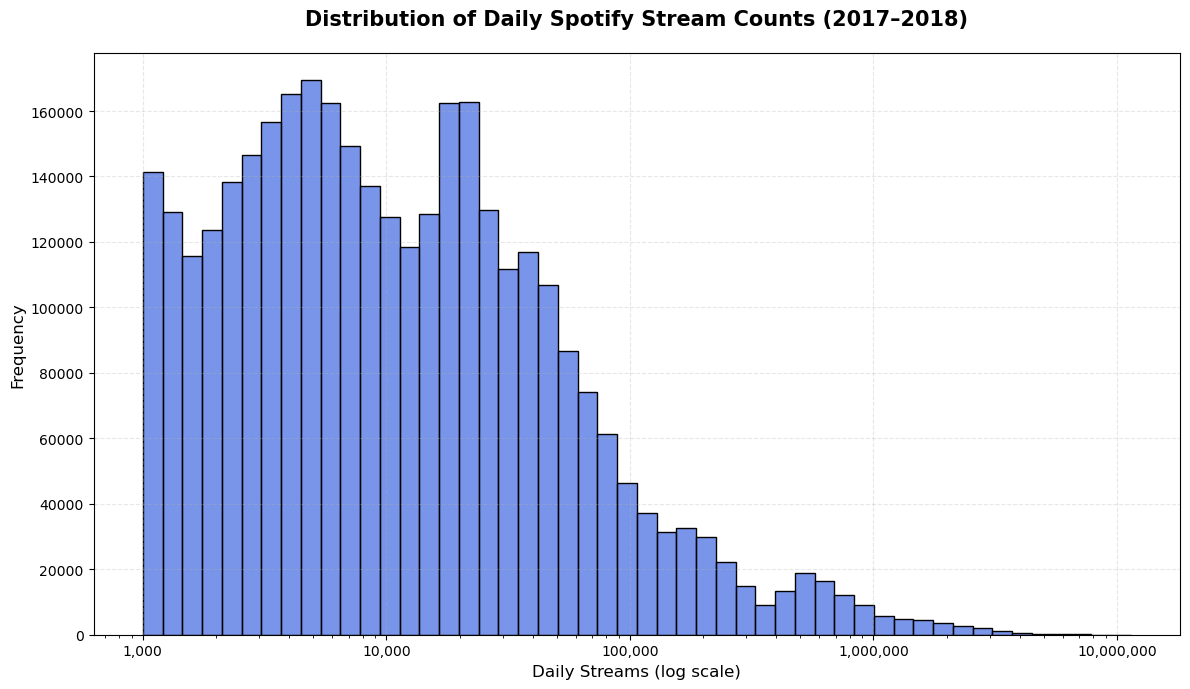

In [99]:
# 1. Select the Streams column for distribution analysis
hist_df = spotify_df[['Streams']].copy()

# 2. Remove any missing or invalid stream values
hist_df = hist_df[hist_df['Streams'].notna()]

# 3. Create a histogram showing the distribution of daily stream counts
plt.figure(figsize=(12, 7))

sns.histplot(
    data=hist_df,
    x='Streams',
    bins=50,
    color='#4169E1',
    edgecolor='black',
    alpha=0.7,
    log_scale=True
)

# 4. Format axes, apply comma formatting, and add gridlines
plt.gca().xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{int(x):,}')
)

plt.xlabel('Daily Streams (log scale)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(True, ls='--', alpha=0.3)

# 5. Add title and finalize the visualization
plt.title(
    'Distribution of Daily Spotify Stream Counts (2017–2018)',
    fontsize=15,
    fontweight='bold',
    pad=20)

plt.tight_layout()
plt.show()

<div style="border: 2px solid black; padding: 10px;">

### Summary

The histogram reveals that daily Spotify stream counts from **2017–2018** follow a strongly right‑skewed, heavy‑tailed distribution. When plotted on a standard linear scale, nearly all observations collapse into the lowest bin because most tracks receive relatively modest daily streams, while only a small number achieve extremely high counts. Applying a logarithmic x‑axis exposes the true structure of the data: a dense concentration of songs in the lower and mid‑range of daily streams, followed by a long tail of increasingly rare high‑stream days. This pattern reflects the typical dynamics of streaming platforms, where a small number of highly popular tracks dominate overall listening activity. The log‑scaled histogram provides a clearer and more interpretable view of how daily stream counts were distributed across the global charts during 2017–2018.


## 4.6 Density Plot — Smoothed Distribution of Daily Stream Counts (2017–2018)

**Steps to Complete**

1. Select the `Streams` column from the dataset for density estimation.
2. Remove any missing or invalid stream values to ensure a clean distribution.
3. Create a kernel density estimate (KDE) plot to visualize the smoothed distribution of daily stream counts.
4. Apply a log scale to the x‑axis so the long‑tailed structure of the data is visible.
5. Format the axes, apply comma formatting to stream values, and add gridlines for readability.
6. Add a title and axis labels to complete the visualization.

---

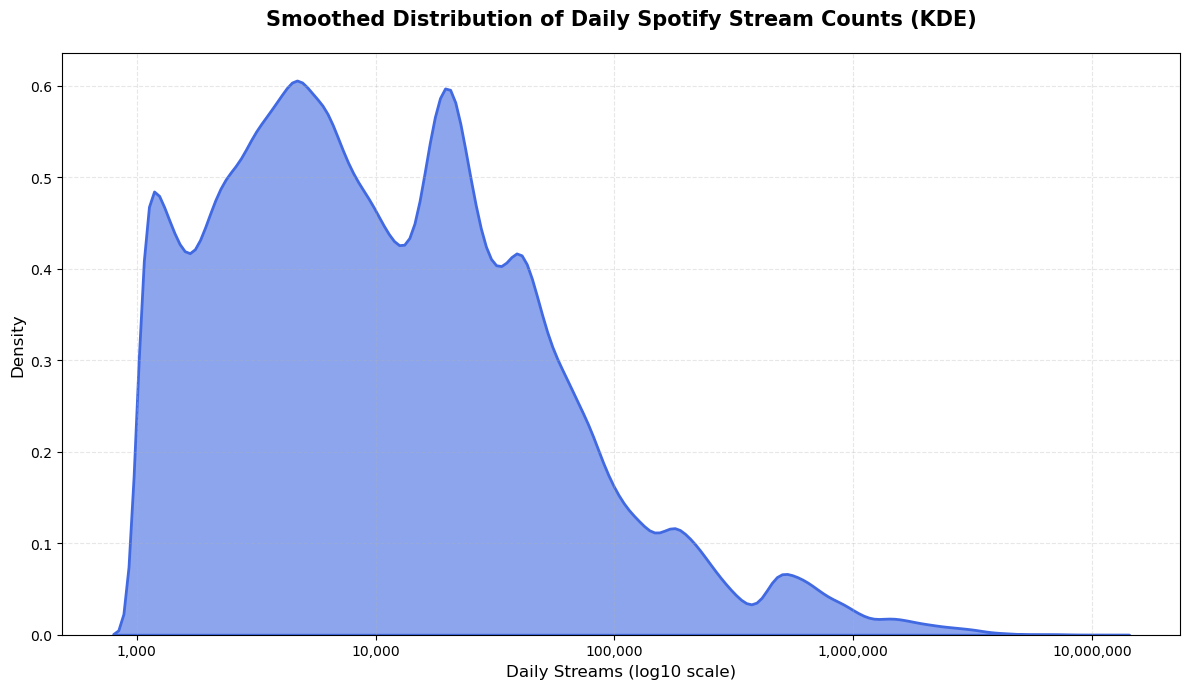

In [100]:
# 1. Select the Streams column for density estimation
density_df = spotify_df[['Streams']].copy()

# 2. Remove missing or invalid values
density_df = density_df[density_df['Streams'].notna()]

# Correcting skew with log10
density_df['Log_Streams'] = np.log10(density_df['Streams'])

# 3. Create a KDE plot on the transformed data
plt.figure(figsize=(12, 7))

sns.kdeplot(
    data=density_df,
    x='Log_Streams',
    fill=True,
    color='#4169E1',   # royal blue
    alpha=0.6,
    linewidth=2
)

# 4. Format x-axis back into readable stream counts


def log_tick_formatter(val, pos):
    """Convert a log10 tick value back into a comma-formatted integer."""
    real_val = 10 ** val
    return f'{int(real_val):,}'


plt.gca().xaxis.set_major_formatter(mticker.FuncFormatter(log_tick_formatter))

# 5. Labels and gridlines
plt.xlabel('Daily Streams (log10 scale)', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.grid(True, ls='--', alpha=0.3)

# 6. Title
plt.title(
    'Smoothed Distribution of Daily Spotify Stream Counts (KDE)',
    fontsize=15,
    fontweight='bold',
    pad=20
)

plt.tight_layout()
plt.show()

<div style="border: 2px solid black; padding: 10px;">

### Summary

The KDE plot provides a smoothed view of the distribution of daily Spotify stream counts for **2017–2018**, using a log‑transformed scale to reveal structure that is otherwise hidden in the extremely skewed raw data. After applying the log10 transformation, the density curve becomes interpretable, showing a clear concentration of tracks within the lower and mid‑range of daily streams, with a gradual tapering toward the highest‑streaming songs. This shape reflects the platform’s long‑tailed popularity pattern: a small number of tracks achieve very high daily streams, while the majority cluster at more modest levels. By formatting the axis back into comma‑separated stream counts, the visualization remains readable while still capturing the true underlying distribution of listening activity during the 2017–2018 period.


<div style="border: 5px solid black; padding: 10px;">

## Reflection

### Straightforward Components:

Several parts of the assignment aligned well with core Python skills and felt natural to complete. In **Activity 7.01**, importing libraries, making the initial web request, and passing the HTML into BeautifulSoup were direct applications of earlier lessons. Extracting `href` tags, printing sample outputs, and iterating through the soup text were also intuitive once the structure of the page became clear. In **Activity 7.02**, loading the API key from a JSON file, constructing the base OMDb URL, and printing JSON responses followed a predictable pattern of reading files, assembling strings, and handling dictionaries. For **Activity 4**, once the dataset was cleaned and organized, generating the required visualizations felt straightforward, especially the line, scatter, and bar charts.

### Challenging Components:

The more difficult parts of the assignment involved parsing irregular data, handling errors, and working with skewed distributions. In **Activity 7.01**, extracting the correct numeric file identifiers and isolating the Top 100 titles required careful use of regular expressions and attention to how the HTML text was structured. The soup text contained noise, blank lines, and inconsistent formatting, so identifying the correct starting index and capturing the next 100 lines took trial and error. In **Activity 7.02**, constructing the full OMDb URL and validating the `"Response"` field introduced complexity, especially when handling failed lookups and ensuring the program behaved correctly for both valid and invalid movie titles. 

### Start / Stop / Continue

- **Start:**  
  Start incorporating more intentional data validation and early checks before parsing or visualizing. Whether scraping HTML, calling an API, or plotting distributions, confirming assumptions up front would reduce debugging time and make the workflow smoother.

- **Stop:**  
  Stop assuming that raw data will be immediately ready for extraction or visualization. Both the Gutenberg HTML and the last dataset I used for **Activity 4** showed that real‑world data often requires cleaning, transformation, or restructuring before it becomes usable. Avoid jumping directly into plotting or parsing without inspecting the data first.

- **Continue:**  
  Continue using a modular, step‑by‑step structure for each activity. Breaking tasks into small, well‑labeled sections made the notebook easier to follow and ensured that each component—scraping, parsing, API calls, and visualization—was independently testable. Maintaining consistent formatting, clear comments, and organized code blocks will remain valuable in future assignments and professional workflows.
